# Drift polynomial distillation
Only constants, powers and monomial interactions. Observed states and teacher-simulated query states are distinguished. Transforms are fit on symbolic training states only; clone groups do not overlap symbolic train/validation/test. Teacher/upstream-PCA exposure remains. Validation selects hyperparameters; test is evaluated after freezing selection.

In [1]:
from pathlib import Path
import os,sys,json
ROOT=Path.cwd()
if ROOT.name=='notebooks':ROOT=ROOT.parent
os.chdir(ROOT);sys.path.insert(0,str(ROOT))
import pandas as pd,numpy as np
from IPython.display import display,Image,Markdown


,degree,alpha,threshold,library_size,active_terms,train_mse,validation_mse,train_nrmse,validation_nrmse
0,1,100.0,0.01,51,2254,6.739158,9.058477,0.711802,0.720467
1,1,100.0,0.05,51,1255,6.914221,9.290072,0.720988,0.729619
2,1,100.0,0.10,51,543,7.690987,10.437915,0.760409,0.773381
3,1,1000.0,0.01,51,2208,7.012417,9.656000,0.726090,0.743850
4,1,1000.0,0.05,51,978,7.331930,10.054059,0.742447,0.759027
5,1,1000.0,0.10,51,343,8.349881,11.429565,0.792313,0.809285
6,2,100.0,0.01,1326,40430,2.355877,5.165816,0.420855,0.544072
7,2,100.0,0.05,1326,2815,4.153794,5.363305,0.558829,0.554374
8,2,100.0,0.10,1326,808,5.752570,7.563999,0.657639,0.658358
9,2,1000.0,0.01,1326,22541,3.259092,5.492299,0.495000,0.561001


50-PC function success: False
50-PC validation NRMSE: 0.5543739085341338
50-PC all-domain validation: 9.065470723506133


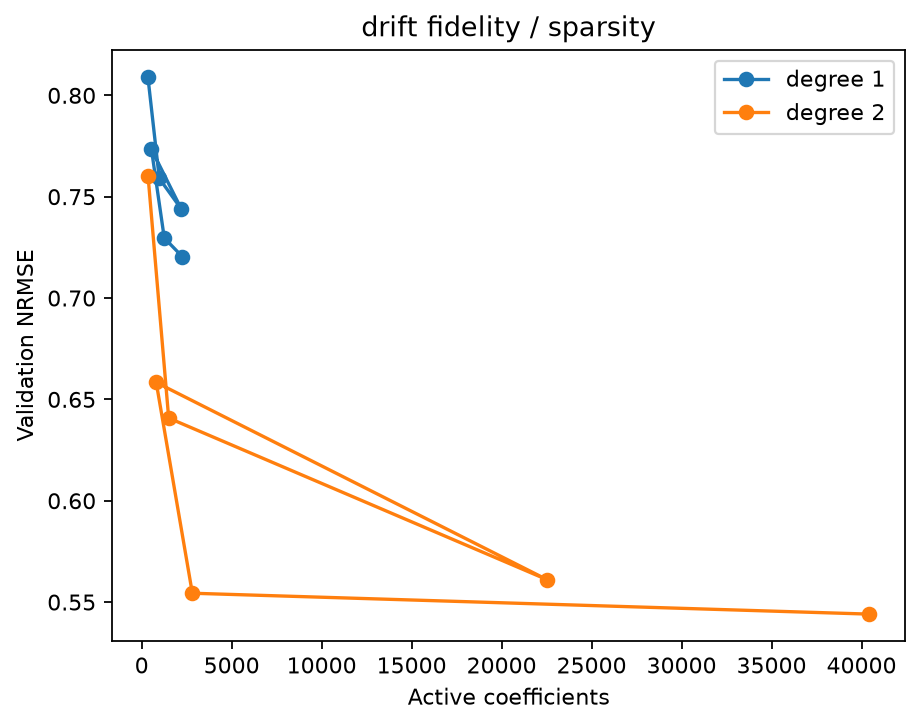

In [2]:
case50=json.loads(Path('outputs/sindy/drift/results.json').read_text())
display(pd.read_csv('outputs/sindy/drift/sweep.csv'))
print('50-PC function success:',case50['function_success'])
print('50-PC validation NRMSE:',case50['validation']['nrmse'])
print('50-PC all-domain validation:',case50['validation_all_domain']['nrmse'])
display(Image(filename='outputs/figures/drift_sparsity.png'))

The 50-PC trial is insufficient, not a symbolic-SDE success. The training-defined norm domain is a local proof-of-concept assumption, with all-domain errors and coverage also reported. Its best sparse selection has material error and extrapolation sensitivity. Degree3 at 50 PCs was not attempted because it would have 23426 features before output expansion.

,degree,alpha,threshold,library_size,active_terms,train_mse,validation_mse,train_nrmse,validation_nrmse
0,1,1.0,0.01,6,30,3.739201,3.211928,0.491186,0.510477
1,1,1.0,0.05,6,26,3.748123,3.209065,0.491772,0.510249
2,1,1.0,0.10,6,22,3.753300,3.220639,0.492112,0.511169
3,1,10.0,0.01,6,30,3.739354,3.210425,0.491197,0.510357
4,1,10.0,0.05,6,26,3.748234,3.207359,0.491779,0.510114
5,1,10.0,0.10,6,22,3.753398,3.219186,0.492118,0.511053
6,1,100.0,0.01,6,29,3.749864,3.203931,0.491886,0.509841
7,1,100.0,0.05,6,27,3.757554,3.208992,0.492390,0.510243
8,1,100.0,0.10,6,23,3.769763,3.224563,0.493190,0.511480
9,2,1.0,0.01,21,102,2.419700,2.242397,0.395128,0.426530


,partition,mse,nrmse,cosine_mean,error_norm_q95,error_norm_max
0,train,2.632990,0.412175,0.918398,6.449167,35.473255
1,validation,2.262767,0.428463,0.878523,6.216783,22.067427
2,test,2.806033,0.471038,0.895039,6.827362,24.654663
3,test_in_domain,2.798675,0.470764,0.895288,6.818798,24.654663


Selected: {'degree': 2, 'alpha': 100.0, 'threshold': 0.1, 'library_size': 21, 'active_terms': 51, 'train_mse': 2.632990301080852, 'validation_mse': 2.262766901240144, 'train_nrmse': 0.41217495720201414, 'validation_nrmse': 0.4284627032638374}
Bootstrap support frequency: 0.8862745098039216
Threshold +/-10%: [{'threshold': 0.09000000000000001, 'active_terms': 54, 'support_jaccard': 0.9444444444444444, 'validation_nrmse': 0.4251642666933662}, {'threshold': 0.11000000000000001, 'active_terms': 42, 'support_jaccard': 0.7884615384615384, 'validation_nrmse': 0.43065935196632427}]
Success gate: True


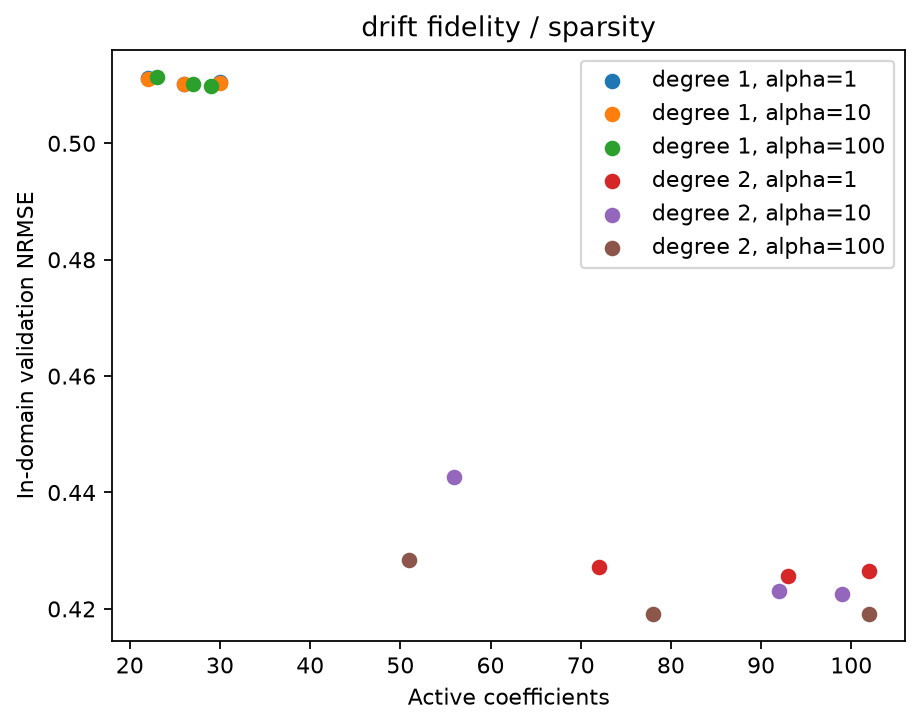

In [3]:
root=Path('outputs/sindy_pc5/drift')
assert (root/'results.json').exists(), 'Five-PC experiment must finish first'
case5=json.loads((root/'results.json').read_text())
display(pd.read_csv(root/'sweep.csv'))
display(pd.DataFrame([{ 'partition':name, **case5[name]} for name in ('train','validation','test','test_in_domain')]))
print('Selected:',case5['selected'])
print('Bootstrap support frequency:',case5['mean_selected_frequency'])
print('Threshold +/-10%:',case5['threshold_jitter'])
print('Success gate:',case5['function_success'])
display(Image(filename='outputs/figures/pc5_drift_sparsity.png'))

In [4]:
from src.distill import PolynomialField
field=PolynomialField.load(root/'model.npz')
display(Markdown((root/'equations.md').read_text()))
print('Shape:',field.predict(np.zeros((3,5))).shape)

# Polynomial field equations

Output units: PC coordinate / day
Only powers and their monomial interactions are used. Coordinate definitions:

z1 = (PC1 - (3.27761887)) / (7.28231268)
z2 = (PC2 - (-2.70247384)) / (3.33683085)
z3 = (PC3 - (0.536390761)) / (5.89675952)
z4 = (PC4 - (-1.36712844)) / (1.96920731)
z5 = (PC5 - (1.27192052)) / (1.72974099)

field_1 = (6.22437817)*1 + (2.05314012)*z1 + (-1.28342338)*z2 + (-1.06973245)*z5 + (-1.30283238)*z1*z4 + (0.695483009)*z1*z5

field_2 = (-1.21971304)*1 + (-0.505890641)*z1 + (1.92874365)*z3 + (0.371718016)*z2^2 + (-0.234210466)*z2*z3 + (-0.223734946)*z3^2

field_3 = (-1.11651844)*1 + (-0.77667931)*z1 + (1.56613134)*z2 + (2.64832114)*z3 + (-0.455448264)*z1*z2 + (-0.307011056)*z1*z3 + (-0.366934693)*z1*z4 + (0.464862815)*z1*z5 + (0.258583408)*z2*z3 + (-0.542948616)*z4*z5

field_4 = (1.50146079)*1 + (1.81471724)*z1 + (-0.745448508)*z2 + (-1.60562712)*z3 + (-0.421804668)*z4 + (-1.16481312)*z1^2 + (0.688746985)*z1*z2 + (0.580348194)*z1*z4 + (-0.326696948)*z1*z5 + (0.278496685)*z3^2 + (0.340807163)*z3*z4 + (-0.32995561)*z4^2

field_5 = (-0.819828052)*1 + (-1.39736803)*z1 + (0.305347086)*z2 + (1.97525336)*z3 + (-0.334929756)*z4 + (-1.49294908)*z5 + (0.782599464)*z1^2 + (-0.463982109)*z1*z2 + (-0.417797409)*z1*z4 + (0.667548884)*z1*z5 + (0.200160437)*z2*z3 + (0.36303569)*z2*z4 + (-0.509599609)*z3^2 + (0.676625616)*z3*z5 + (0.240426744)*z4^2 + (-0.373001498)*z4*z5 + (-0.369169519)*z5^2

Shape: (3, 5)


NRMSE denominator is RMS teacher target, not its standard deviation. Thresholds use training-RMS-scaled library/targets and retained ridge. Bootstrap holds the coordinate transform fixed and resamples whole clone groups; only five replicates are used for this demo. PC formulas are teacher approximations, not gene-level mechanisms or ground-truth SDE discovery.